<a href="https://colab.research.google.com/github/honmin21/Data_Science_Tasks/blob/main/LOAN_APPROVAL_CLASSIFIER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LOAN APPROVAL CLASSIFICATION USING SVM

In [1]:
#import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import load_diabetes
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv('/content/loan_data.csv')
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


**DATA CLEANING**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [5]:
missing_values = df.isnull().sum()
print(missing_values)

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


In [6]:
#handle outliers
df =df[df['person_age'] <=100]
df.describe()


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,44993.000000,4.499300e+04,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000
mean,27.748428,7.990845e+04,5.394528,9583.176761,11.006448,0.139736,5.866557,632.585713,0.222257
std,5.909737,6.332213e+04,5.927159,6314.802655,2.978985,0.087207,3.877167,50.402411,0.415767
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.719500e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704600e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.577800e+04,8.000000,12237.000000,12.990000,0.190000,8.000000,670.000000,0.000000
max,94.000000,2.448661e+06,76.000000,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000


**VISUALIzATION**

<Axes: xlabel='loan_status', ylabel='Count'>

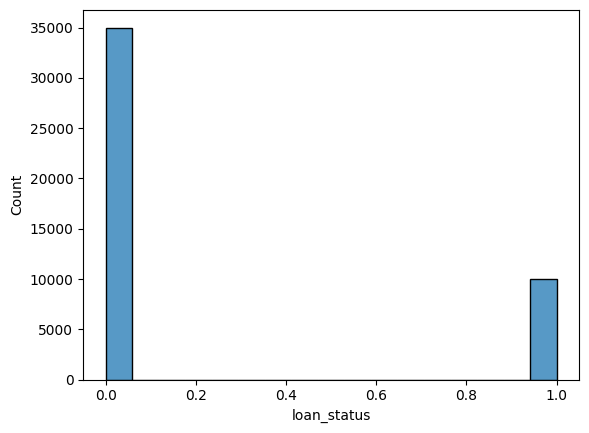

In [7]:
sns.histplot(x = 'loan_status', data = df)

<Axes: xlabel='person_age', ylabel='count'>

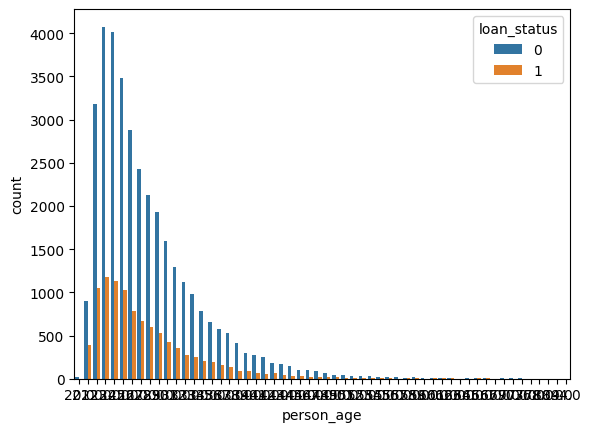

In [8]:
sns.countplot(x ='person_age', data = df,hue = 'loan_status' )

<Axes: xlabel='person_age', ylabel='Count'>

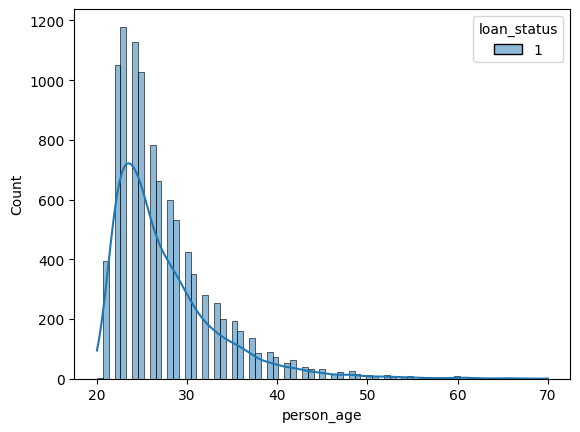

In [11]:
sns.histplot(x = 'person_age', data = df[df["loan_status"]==1],hue='loan_status',kde = True)

<Axes: xlabel='credit_score', ylabel='Count'>

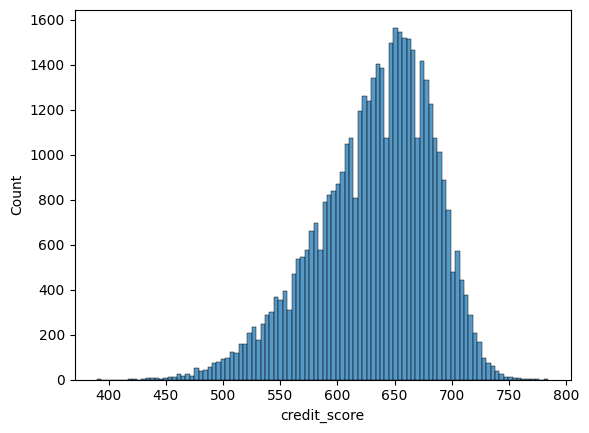

In [15]:
sns.histplot(x ='credit_score',data = df)

<Axes: >

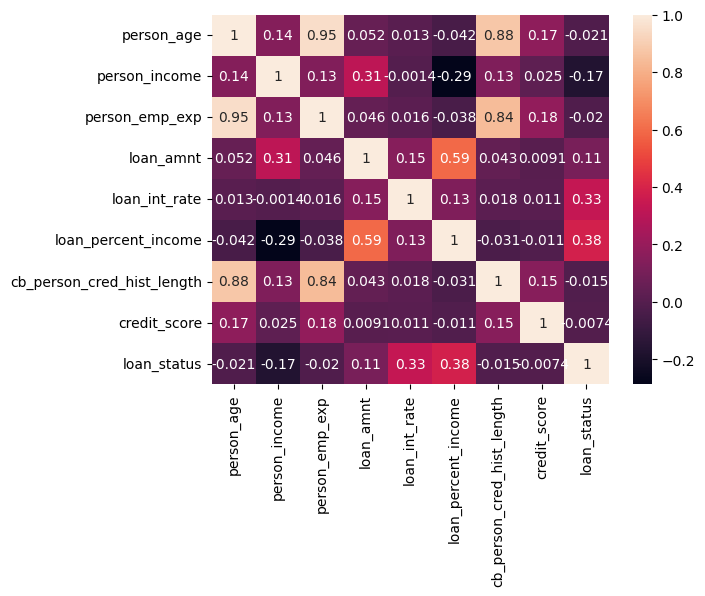

In [19]:
num_cols =[col for col in df.columns if df[col].dtype != object]
data = df[num_cols].corr()
sns.heatmap(data,annot = True)

**MODEL TRAINING**

In [22]:
#scaling

In [38]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# Identify categorical columns
categorical_cols = X.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data preparation complete.")

Data preparation complete.


In [39]:
# Initialize and train the SVM model
svm_model = SVC()
svm_model.fit(X_train, y_train)

print("SVM model training complete.")

SVM model training complete.


In [40]:
# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)


Accuracy: 0.9169
Confusion Matrix:
[[6756  246]
 [ 502 1495]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      7002
           1       0.86      0.75      0.80      1997

    accuracy                           0.92      8999
   macro avg       0.89      0.86      0.87      8999
weighted avg       0.91      0.92      0.91      8999



In [41]:
print("Training Eff: ",svm_model.score(X_train,y_train))
print("Testing Eff: ",svm_model.score(X_test,y_test))

Training Eff:  0.9215146968939267
Testing Eff:  0.9168796532948106


In [44]:
new_data_raw = df.iloc[0:1, :-1]

# Apply one-hot encoding to new_data_raw, ensuring columns match the training data X
categorical_cols_for_pred = new_data_raw.select_dtypes(include='object').columns
new_data_encoded = pd.get_dummies(new_data_raw, columns=categorical_cols_for_pred, drop_first=True)

# Align columns of new_data_encoded with the columns of X (the full feature set after one-hot encoding)
# This ensures that even if a category is missing in the single new_data_raw row, the column exists with a 0.
new_data_aligned = new_data_encoded.reindex(columns=X.columns, fill_value=0)

# Scale the aligned new data
new_data_scaled = scaler.transform(new_data_aligned)

# Make prediction
pred = svm_model.predict(new_data_scaled)

if pred == 0:
  print("Loan not approved")
else:
  print("Loan Approved")

Loan Approved
